This Notebook is designed to perform **multi-class classification** on mycetoma species using **Region of Interest (ROI)** images that have been pre-processed with **Macenko stain normalization**. The key objective is to build a machine learning pipeline to distinguish between four different species of mycetoma using histopathology images.

The notebook focuses on using **MONAI**, a framework for AI in healthcare imaging, and a **DenseNet121** deep learning model. It demonstrates a complete workflow from data loading and preparation to model training, validation, and final evaluation, using manually annotated masks to ensure that the model learns from the relevant areas of the images.

In [ ]:
#Mount Drive: This step connects the notebook to your Google Drive to access the dataset.
from glob import glob
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Install Libraries: This installs the necessary MONAI and other Python libraries for deep learning and data handling.
!pip install -q "monai-weekly[pillow, tqdm]" #Install required dependencies
!pip install -q matplotlib
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 92.5 MB/s eta 0:00:00


In [ ]:
import os
root_dir = '/content/drive'
print(root_dir)


/content/drive


In [ ]:
#Import Libraries: This imports all required modules and classes for image processing, classification metrics, and the DenseNet121 model.
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
from sklearn.metrics import classification_report
import torch
from monai.apps import download_and_extract
from monai.config import print_config
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import *
from monai.data import Dataset, DataLoader, decollate_batch
from monai.utils import set_determinism

#print_config()

In [ ]:
#Set Data Directory: This defines the directory where the Macenko stain-normalized ROI images are stored.
train_dir = '/content/drive/MyDrive/roi_images_macenko_mask2/'


In [ ]:
#Load Data and Classes: This finds and lists the four mycetoma species classes and gathers file paths for all images in the dataset.
#train
class_names0 = os.listdir(train_dir)
class_names = sorted(class_names0)
print(class_names)
num_class = len(class_names)

image_files = [[os.path.join(train_dir, class_name, x)
               for x in os.listdir(os.path.join(train_dir, class_name))]
               for class_name in class_names]

image_file_list = []
image_label_list = []
for i, class_name in enumerate(class_names):
    image_file_list.extend(image_files[i])
    image_label_list.extend([i] * len(image_files[i]))

num_total = len(image_label_list)


['actionmadureapelletrii', 'falciformisporasenegalensis', 'madurellamycetomatis', 'streptomycessomaliesnis']


In [ ]:
print(num_class)

4


In [ ]:
# Split the dataset into training (70%), validation (10%), and testing (20%)
from sklearn.model_selection import train_test_split

# First split: Training set and remaining (30% for validation + test)
trainX, remainingX, trainY, remainingY = train_test_split(image_file_list, image_label_list, test_size=0.3, random_state=69)

# Second split: Validation set (10%) and test set (20%)
valX, testX, valY, testY = train_test_split(remainingX, remainingY, test_size=0.67, random_state=69)  # 2/3 of 30% = 20%

print("Dataset sizes:")
print(f"Training: {len(trainX)} images")
print(f"Validation: {len(valX)} images")
print(f"Testing: {len(testX)} images")


Dataset sizes:
Training: 926 images
Validation: 131 images
Testing: 267 images


In [ ]:
# Ensure the split percentages are correct
assert len(trainX) + len(valX) + len(testX) == len(image_file_list)
assert len(trainY) + len(valY) + len(testY) == len(image_label_list)


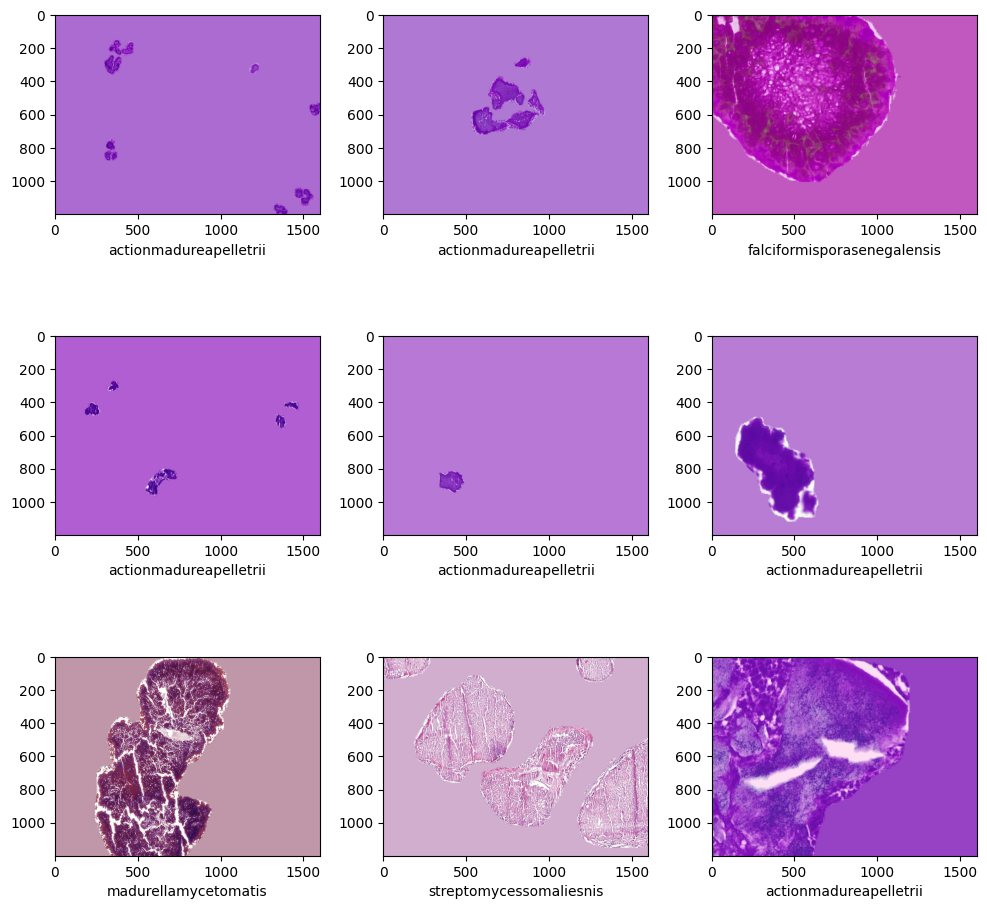

In [ ]:
plt.subplots(3,3, figsize=(10,10))
for i,k in enumerate(np.random.randint(num_total, size=9)):
    im = Image.open(image_file_list[k])
    arr = np.array(im)
    #print(arr.shape)
    plt.subplot(3,3, i+1)
    plt.xlabel(class_names[image_label_list[k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()

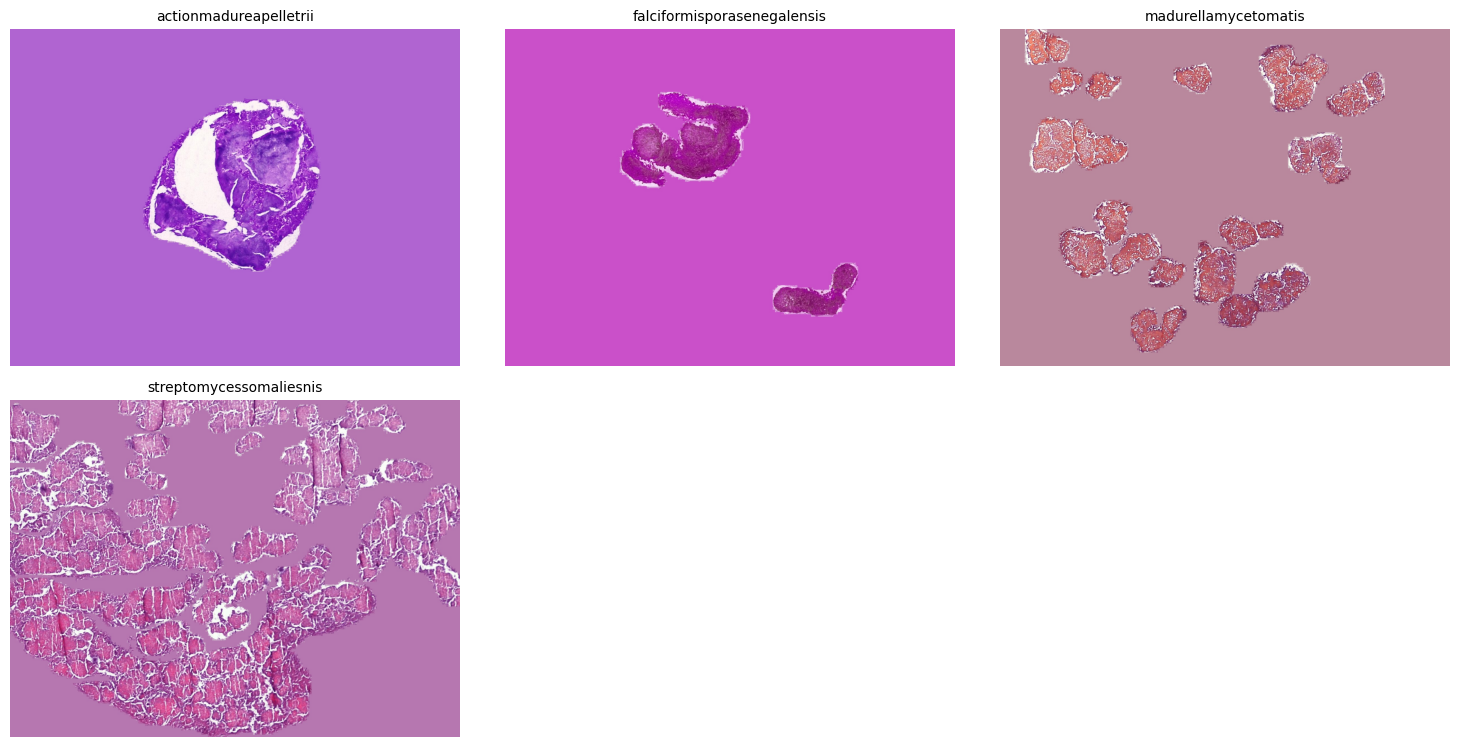

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Assuming class_names, image_file_list, and image_label_list are already defined
class_to_image = {}  # Dictionary to hold one image path per class

# Select one image for each class
for img_path, label in zip(image_file_list, image_label_list):
    class_name = class_names[label]
    if class_name not in class_to_image:
        class_to_image[class_name] = img_path
    if len(class_to_image) == num_class:  # Stop once we have one image per class
        break

# Plot the images
plt.figure(figsize=(15, 15))
for i, (class_name, img_path) in enumerate(class_to_image.items()):
    im = Image.open(img_path)
    arr = np.array(im)
    plt.subplot(4, 3, i + 1)  # Adjust grid size if needed
    plt.title(class_name, fontsize=10)
    plt.axis('off')
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)

plt.tight_layout()
plt.show()


In [ ]:
train_x=np.array(trainX)
train_y=np.array(trainY)
val_x=np.array(valX)
val_y=np.array(valY)
test_x=np.array(testX)
test_y=np.array(testY)

In [ ]:
#Define Transforms: This section prepares data for the deep learning model by defining a series of transformations, such as resize, normalize, and convert images to tensors.
train_transforms = Compose(
    [
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
        RandFlip(spatial_axis=0, prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
        Resize((300,300)),

    ]
)

val_transforms = Compose([LoadImage(image_only=True), EnsureChannelFirst(), Resize((300,300)),
        ScaleIntensity()])

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_class)])

In [ ]:
#Create Datasets and Loaders: This applies the defined transforms to the image lists
#and creates PyTorch Dataset and DataLoader objects for efficient processing during training and validation.
class MedNISTDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = MedNISTDataset(train_x, train_y, train_transforms)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_ds = MedNISTDataset(val_x, val_y, val_transforms)
val_loader = DataLoader(val_ds, batch_size=32)

test_ds = MedNISTDataset(test_x, test_y, val_transforms)
test_loader = DataLoader(test_ds, batch_size=32)

In [ ]:
def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax


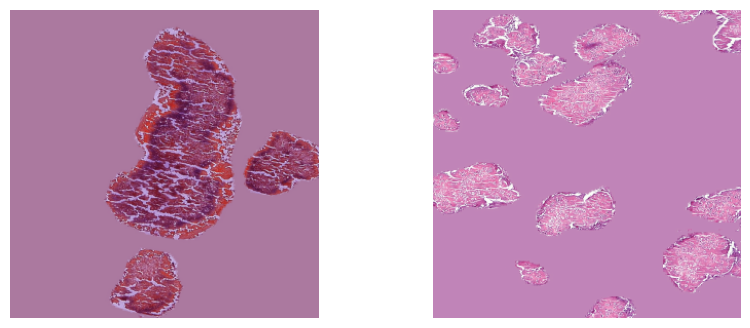

In [ ]:
# change this to the trainloader or testloader
data_iter = iter(train_loader)

images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=2)
for ii in range(2):
    ax = axes[ii]
#     helper.imshow(images[ii], ax=ax, normalize=False)
    imshow(images[ii], ax=ax, normalize=False)

In [ ]:
#Set up the Model: This initializes the DenseNet121 convolutional neural network, a common architecture for image
#classification, with a pre-trained model and adjusts the final layer for four output classes (mycetoma species).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=num_class).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
max_epochs = 15
val_interval = 1
auc_metric = ROCAUCMetric()

In [ ]:
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            y = torch.tensor([], dtype=torch.long, device=device)
            for val_data in val_loader:
                val_images, val_labels = (
                    val_data[0].to(device),
                    val_data[1].to(device),
                )
                y_pred = torch.cat([y_pred, model(val_images)], dim=0)
                y = torch.cat([y, val_labels], dim=0)
            y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)
            acc_value = torch.eq(y_pred.argmax(dim=1), y)
            acc_metric = acc_value.sum().item() / len(acc_value)
            if result > best_metric:
                best_metric = result
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current accuracy: {acc_metric:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )

print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")


----------
epoch 1/15
1/28, train_loss: 1.5676
2/28, train_loss: 1.5098
3/28, train_loss: 1.5161
4/28, train_loss: 1.4490
5/28, train_loss: 1.4973
6/28, train_loss: 1.4430
7/28, train_loss: 1.3689
8/28, train_loss: 1.3900
9/28, train_loss: 1.3424
10/28, train_loss: 1.3996
11/28, train_loss: 1.4295
12/28, train_loss: 1.2546
13/28, train_loss: 1.1750
14/28, train_loss: 1.2697
15/28, train_loss: 1.2626
16/28, train_loss: 1.1290
17/28, train_loss: 1.2227
18/28, train_loss: 1.2548
19/28, train_loss: 1.1671
20/28, train_loss: 1.2307
21/28, train_loss: 1.2608
22/28, train_loss: 1.0726
23/28, train_loss: 1.2207
24/28, train_loss: 1.0191
25/28, train_loss: 1.0658
26/28, train_loss: 1.0886
27/28, train_loss: 1.1444
28/28, train_loss: 1.0627
29/28, train_loss: 0.9488
epoch 1 average loss: 1.2677
saved new best metric model
current epoch: 1 current AUC: 0.9229 current accuracy: 0.4198 best AUC: 0.9229 at epoch: 1
----------
epoch 2/15
1/28, train_loss: 1.0224
2/28, train_loss: 0.9354
3/28, train_l

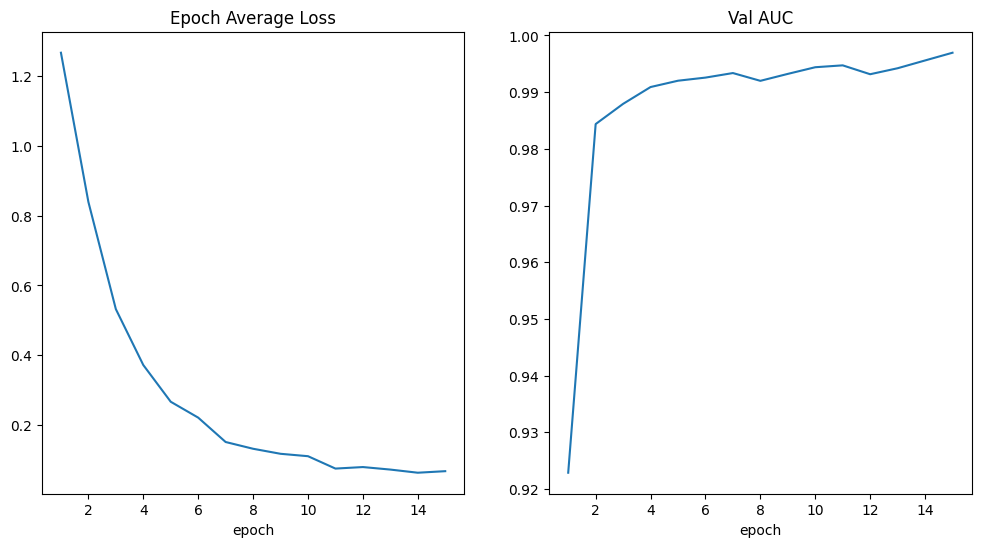

In [ ]:
#Plot Performance: This step visualizes the training and validation loss and accuracy over time to provide a clear view of the model's learning process.
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val AUC")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

In [ ]:
#Test and Evaluation: This loads the best-performing model and evaluates it on the unseen test dataset.
model.load_state_dict(torch.load("best_metric_model.pth"))
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data[0].to(device),
            test_data[1].to(device),
        )
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

In [ ]:
#Save the model
torch.save(model.state_dict(), "/content/drive/MyDrive/best_metric_model.pth")


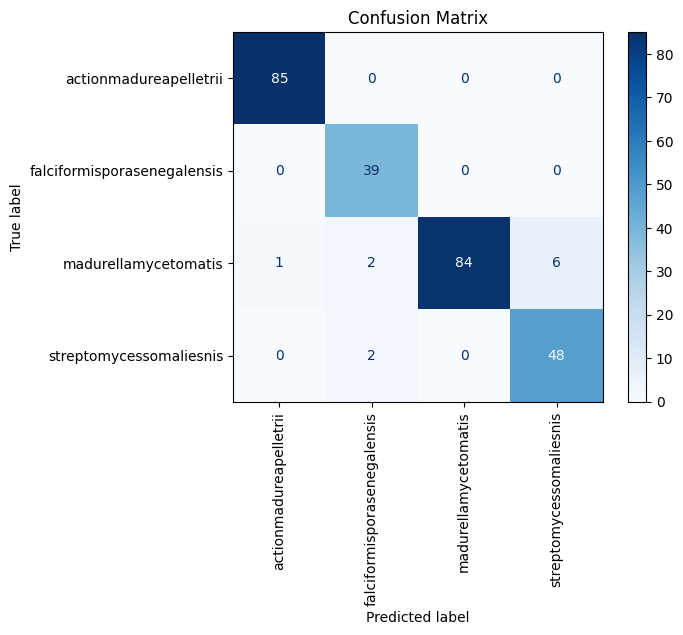

In [ ]:
#Generate Classification Report: This provides a detailed report of the model's performance, which includes precision, recall, and f1-score for each of the four mycetoma species.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                             precision    recall  f1-score   support

     actionmadureapelletrii     0.9884    1.0000    0.9942        85
falciformisporasenegalensis     0.9070    1.0000    0.9512        39
       madurellamycetomatis     1.0000    0.9032    0.9492        93
    streptomycessomaliesnis     0.8889    0.9600    0.9231        50

                   accuracy                         0.9588       267
                  macro avg     0.9461    0.9658    0.9544       267
               weighted avg     0.9619    0.9588    0.9589       267

